# Imbalanced Model Testing without Class Weights

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("logs/WednesdayTraffic_cleaned.csv")

In [3]:
X = df.drop("Label", axis=1)
y = df["Label"]

print(X.shape)
print(y.shape)

X.dtypes

(1031018, 79)
(1031018,)


Dst Port           int64
Protocol           int64
Timestamp         object
Flow Duration      int64
Tot Fwd Pkts       int64
                  ...   
Active Min         int64
Idle Mean        float64
Idle Std         float64
Idle Max           int64
Idle Min           int64
Length: 79, dtype: object

In [4]:
df = df.drop("Timestamp", axis=1)

X = df.drop("Label", axis=1)
y = df["Label"]

X.columns

Index(['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
       'Fwd Seg Siz

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nTraining label proportions:")
print(y_train.value_counts(normalize=True))

print("\nTest label distribution:")
print(y_test.value_counts())

print("\nTest label proportions:")
print(y_test.value_counts(normalize=True))

Training set: (824814, 78)
Test set: (206204, 78)

Training label distribution:
Label
1    536153
0    288661
Name: count, dtype: int64

Training label proportions:
Label
1    0.650029
0    0.349971
Name: proportion, dtype: float64

Test label distribution:
Label
1    134038
0     72166
Name: count, dtype: int64

Test label proportions:
Label
1    0.650026
0    0.349974
Name: proportion, dtype: float64


In [6]:
# Keep the original split
X_train_imb = X_train.copy()
y_train_imb = y_train.copy()

print("Imbalanced training distribution:")
print(y_train_imb.value_counts())

Imbalanced training distribution:
Label
1    536153
0    288661
Name: count, dtype: int64


# Logistic Regression (Unscaled Pipeline)

In [7]:
log_pipe_unscaled = Pipeline([
    ("model", LogisticRegression(max_iter=1000))
])

log_pipe_unscaled.fit(X_train_imb, y_train_imb)

log_pred_unscaled = log_pipe_unscaled.predict(X_test)

print("Logistic Regression (Unscaled) Results")
print(classification_report(y_test, log_pred_unscaled))

Logistic Regression (Unscaled) Results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72166
           1       1.00      1.00      1.00    134038

    accuracy                           1.00    206204
   macro avg       1.00      1.00      1.00    206204
weighted avg       1.00      1.00      1.00    206204



In [8]:
train_pred_unscaled = log_pipe_unscaled.predict(X_train_imb)
print("Training performance - Logistic Regression (Unscaled)")
print(classification_report(y_train_imb, train_pred_unscaled))

y_pred_unscaled = log_pipe_unscaled.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_unscaled))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_unscaled))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_unscaled))

Training performance - Logistic Regression (Unscaled)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    288661
           1       1.00      1.00      1.00    536153

    accuracy                           1.00    824814
   macro avg       1.00      1.00      1.00    824814
weighted avg       1.00      1.00      1.00    824814

Accuracy: 0.9999951504335512

Confusion Matrix:
[[ 72165      1]
 [     0 134038]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72166
           1       1.00      1.00      1.00    134038

    accuracy                           1.00    206204
   macro avg       1.00      1.00      1.00    206204
weighted avg       1.00      1.00      1.00    206204



# Logistic Regression (Scaled Pipeline)

In [9]:
log_pipe_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

log_pipe_scaled.fit(X_train_imb, y_train_imb)

log_pred_scaled = log_pipe_scaled.predict(X_test)

print("Logistic Regression (Scaled) Results")
print(classification_report(y_test, log_pred_scaled))

Logistic Regression (Scaled) Results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72166
           1       1.00      1.00      1.00    134038

    accuracy                           1.00    206204
   macro avg       1.00      1.00      1.00    206204
weighted avg       1.00      1.00      1.00    206204



In [10]:
train_pred_scaled = log_pipe_scaled.predict(X_train_imb)
print("Training performance - Logistic Regression (Scaled)")
print(classification_report(y_train_imb, train_pred_scaled))

y_pred_scaled = log_pipe_scaled.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_scaled))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_scaled))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_scaled))

Training performance - Logistic Regression (Scaled)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    288661
           1       1.00      1.00      1.00    536153

    accuracy                           1.00    824814
   macro avg       1.00      1.00      1.00    824814
weighted avg       1.00      1.00      1.00    824814

Accuracy: 0.999980601734205

Confusion Matrix:
[[ 72162      4]
 [     0 134038]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72166
           1       1.00      1.00      1.00    134038

    accuracy                           1.00    206204
   macro avg       1.00      1.00      1.00    206204
weighted avg       1.00      1.00      1.00    206204



# Decision Tree Model

In [11]:
tree_pipe = Pipeline([
    ("model", DecisionTreeClassifier(
        max_depth=20,
        min_samples_split=10,
        random_state=42
    ))
])

tree_pipe.fit(X_train_imb, y_train_imb)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If fl

In [12]:
tree_pred = tree_pipe.predict(X_test)

print("Accuracy:", accuracy_score(y_test, tree_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tree_pred))

print("\nClassification Report:")
print(classification_report(y_test, tree_pred))

tree_model = tree_pipe.named_steps["model"]
importance = pd.Series(tree_model.feature_importances_, index=X_train_imb.columns)
print(importance.sort_values(ascending=False).head(10))

Accuracy: 0.9999903008671025

Confusion Matrix:
[[ 72166      0]
 [     2 134036]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72166
           1       1.00      1.00      1.00    134038

    accuracy                           1.00    206204
   macro avg       1.00      1.00      1.00    206204
weighted avg       1.00      1.00      1.00    206204

Dst Port            0.992605
Fwd Pkts/s          0.007371
Fwd Seg Size Min    0.000021
Flow IAT Max        0.000003
Flow Duration       0.000000
Protocol            0.000000
TotLen Bwd Pkts     0.000000
Fwd Pkt Len Max     0.000000
Fwd Pkt Len Min     0.000000
Fwd Pkt Len Mean    0.000000
dtype: float64


In [13]:
# Just to test if there is any data leakage / overfitting
train_pred = tree_pipe.predict(X_train_imb)

print(classification_report(y_train_imb, train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    288661
           1       1.00      1.00      1.00    536153

    accuracy                           1.00    824814
   macro avg       1.00      1.00      1.00    824814
weighted avg       1.00      1.00      1.00    824814



# Random Forest

In [14]:
rf_pipe = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train_imb, y_train_imb)

rf_pred = rf_pipe.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Accuracy: 1.0

Confusion Matrix:
[[ 72166      0]
 [     0 134038]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     72166
           1       1.00      1.00      1.00    134038

    accuracy                           1.00    206204
   macro avg       1.00      1.00      1.00    206204
weighted avg       1.00      1.00      1.00    206204



Dst Port             0.143762
Fwd Pkt Len Max      0.104551
Fwd Pkt Len Mean     0.093642
Fwd Seg Size Avg     0.070065
Fwd Pkt Len Std      0.069337
TotLen Fwd Pkts      0.064570
Init Bwd Win Byts    0.064426
Tot Fwd Pkts         0.064269
Subflow Fwd Pkts     0.059495
Fwd Header Len       0.054961
dtype: float64


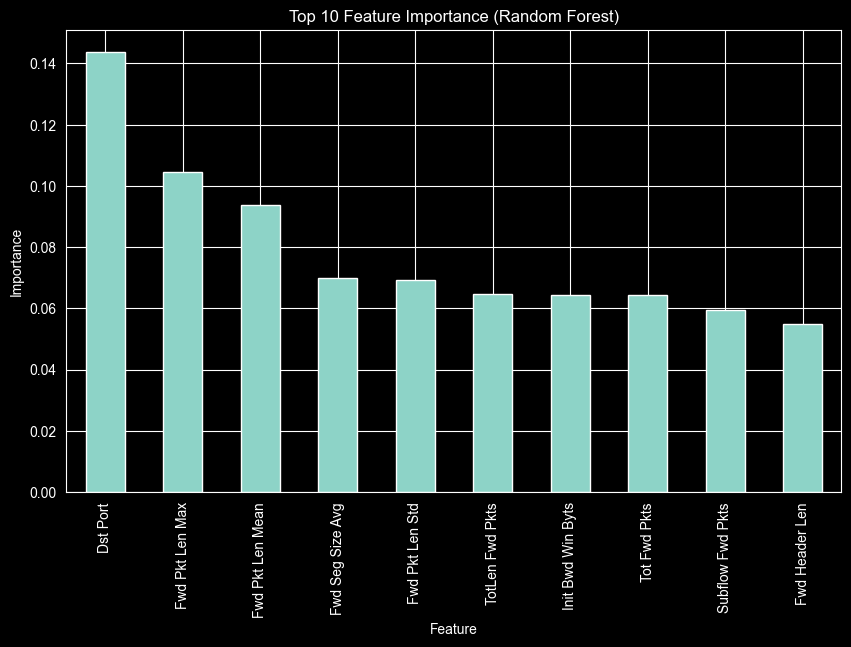

In [15]:
rf_model = rf_pipe.named_steps["model"]

importance = pd.Series(rf_model.feature_importances_, index=X_train_imb.columns)
print(importance.sort_values(ascending=False).head(10))

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.show()

In [16]:
scores = cross_val_score(
    rf_pipe,
    X_train_imb,
    y_train_imb,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print("Cross-validation scores:", scores)
print("Average F1 score:", np.mean(scores))

Cross-validation scores: [1. 1. 1. 1. 1.]
Average F1 score: 1.0


Lets do an interesting experiment again, where we test performance to ensure there is no leakage. 
If we shuffle the labels and the model performance collapses, that supports the idea that the pipeline is learning real structure instead of memorizing labels.

In [17]:
y_shuffled = np.random.permutation(y_train_imb)

rf_shuffle_pipe = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ))
])

rf_shuffle_pipe.fit(X_train_imb, y_shuffled)

shuffle_pred = rf_shuffle_pipe.predict(X_test)

print("Accuracy:", accuracy_score(y_test, shuffle_pred))
print(classification_report(y_test, shuffle_pred))

Accuracy: 0.6502832146806076
              precision    recall  f1-score   support

           0       0.75      0.00      0.00     72166
           1       0.65      1.00      0.79    134038

    accuracy                           0.65    206204
   macro avg       0.70      0.50      0.40    206204
weighted avg       0.68      0.65      0.51    206204

